# ❤️ Notebook 3 — Biological Pulse
**Dataset:** `synthetic_coffee_health_10000.csv` (10,000 rows)

**Story:** This is where coffee meets the human body. Caffeine intake drives heart rate — the literal pulse.

**Outputs:** `data/processed/bio_processed.csv` · `models/heart_rate_predictor.pkl`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings, os, joblib
warnings.filterwarnings('ignore')

ROOT = os.path.abspath('..')
RAW  = os.path.join(ROOT,'data','raw')
PROC = os.path.join(ROOT,'data','processed')
MDL  = os.path.join(ROOT,'models')
os.makedirs(PROC, exist_ok=True)
os.makedirs(MDL,  exist_ok=True)

sns.set_theme(style='darkgrid')
C_PULSE='#E84855'; C_CALM='#2E86AB'; C_WARM='#F5A623'; C_BROWN='#6F4E37'
print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Load & Inspect

In [2]:
df = pd.read_csv(os.path.join(RAW,'synthetic_coffee_health_10000.csv'))
print(f'Shape: {df.shape}')
print('\nColumns:', df.columns.tolist())
print('\nSleep_Quality:', df['Sleep_Quality'].value_counts().to_dict())
print('Stress_Level:', df['Stress_Level'].value_counts().to_dict())
df.describe()

Shape: (10000, 16)

Columns: ['ID', 'Age', 'Gender', 'Country', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'Sleep_Quality', 'BMI', 'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours', 'Health_Issues', 'Occupation', 'Smoking', 'Alcohol_Consumption']

Sleep_Quality: {'Good': 5637, 'Fair': 2050, 'Excellent': 1352, 'Poor': 961}
Stress_Level: {'Low': 6989, 'Medium': 2050, 'High': 961}


,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


## 2 · Clean & Encode

In [3]:
# Ordinal encode categorical columns
SQ_MAP = {'Poor':1, 'Fair':2, 'Good':3, 'Excellent':4}
SL_MAP = {'Low':1, 'Medium':2, 'High':3}
GD_MAP = {'Male':0, 'Female':1, 'Other':2}

df['Sleep_Quality_num'] = df['Sleep_Quality'].map(SQ_MAP)
df['Stress_Level_num']  = df['Stress_Level'].map(SL_MAP)
df['Gender_enc']        = df['Gender'].map(GD_MAP)

# Remove physiologically impossible heart rates
df = df[(df['Heart_Rate'] >= 40) & (df['Heart_Rate'] <= 200)]
df = df[df['Caffeine_mg'] >= 0]

print(f'Clean shape: {df.shape}')
print(f"Heart Rate range: {df['Heart_Rate'].min()} – {df['Heart_Rate'].max()} BPM")
print(f"Caffeine range: {df['Caffeine_mg'].min()} – {df['Caffeine_mg'].max()} mg")
df[['Age','Coffee_Intake','Caffeine_mg','Heart_Rate','Sleep_Hours','BMI']].describe()

Clean shape: (10000, 19)
Heart Rate range: 50 – 109 BPM
Caffeine range: 0.0 – 780.3 mg


,Age,Coffee_Intake,Caffeine_mg,Heart_Rate,Sleep_Hours,BMI
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,34.949100,2.509230,238.411010,70.617800,6.636220,23.986860
std,11.160939,1.450248,137.748815,9.822951,1.222055,3.906411
min,18.000000,0.000000,0.000000,50.000000,3.000000,15.000000
25%,26.000000,1.500000,138.750000,64.000000,5.800000,21.300000
50%,34.000000,2.500000,235.400000,71.000000,6.600000,24.000000
75%,43.000000,3.500000,332.025000,77.000000,7.500000,26.600000
max,80.000000,8.200000,780.300000,109.000000,10.000000,38.200000


## 3 · EDA — Coffee & Health

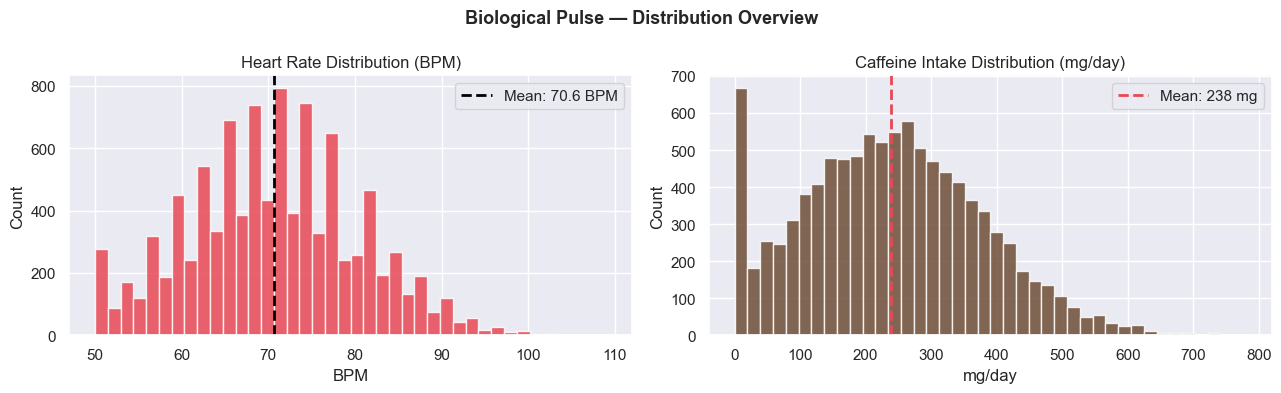

In [4]:
# ── 3a. Heart Rate distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Heart_Rate'], bins=40, color=C_PULSE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['Heart_Rate'].mean(), color='black', ls='--', lw=2,
                label=f"Mean: {df['Heart_Rate'].mean():.1f} BPM")
axes[0].set(title='Heart Rate Distribution (BPM)', xlabel='BPM', ylabel='Count')
axes[0].legend()

axes[1].hist(df['Caffeine_mg'], bins=40, color=C_BROWN, edgecolor='white', alpha=0.85)
axes[1].axvline(df['Caffeine_mg'].mean(), color=C_PULSE, ls='--', lw=2,
                label=f"Mean: {df['Caffeine_mg'].mean():.0f} mg")
axes[1].set(title='Caffeine Intake Distribution (mg/day)', xlabel='mg/day', ylabel='Count')
axes[1].legend()

plt.suptitle('Biological Pulse — Distribution Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC,'bio_01_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

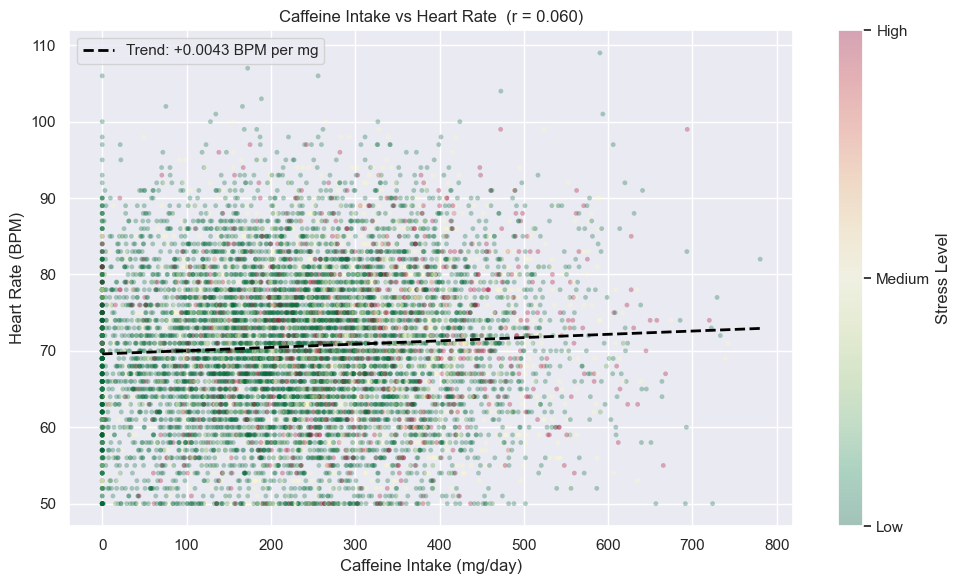

In [5]:
# ── 3b. Caffeine vs Heart Rate (the key scatter) ──────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    df['Caffeine_mg'], df['Heart_Rate'],
    c=df['Stress_Level_num'], cmap='RdYlGn_r',
    alpha=0.3, s=12, edgecolors='none'
)
cb = plt.colorbar(sc, ax=ax)
cb.set_ticks([1,2,3])
cb.set_ticklabels(['Low','Medium','High'])
cb.set_label('Stress Level')

m, b = np.polyfit(df['Caffeine_mg'], df['Heart_Rate'], 1)
xs = np.linspace(0, df['Caffeine_mg'].max(), 100)
ax.plot(xs, m*xs+b, color='black', lw=2, ls='--',
        label=f'Trend: +{m:.4f} BPM per mg')
r = df[['Caffeine_mg','Heart_Rate']].corr().iloc[0,1]
ax.set(title=f'Caffeine Intake vs Heart Rate  (r = {r:.3f})',
       xlabel='Caffeine Intake (mg/day)', ylabel='Heart Rate (BPM)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROC,'bio_02_caffeine_hr.png'), dpi=150, bbox_inches='tight')
plt.show()

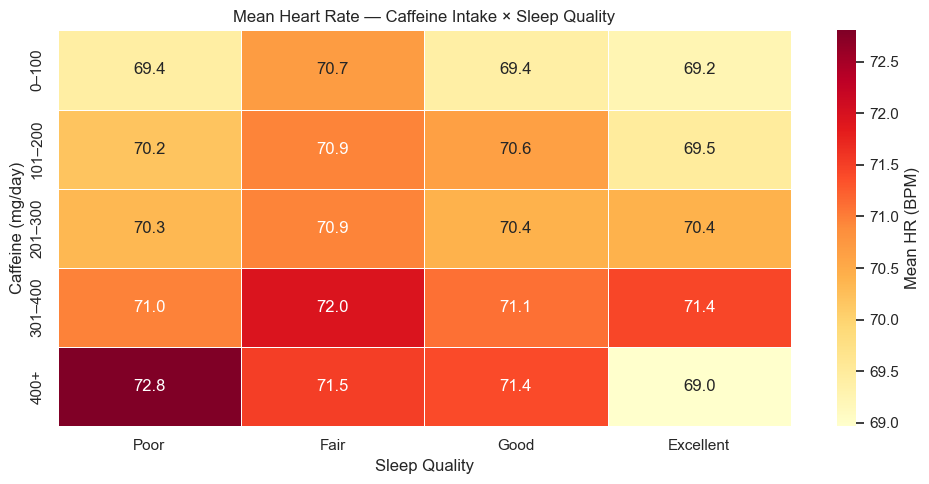

In [6]:
# ── 3c. Heatmap — Caffeine bins vs Sleep Quality ───────────────
df['Caffeine_bin'] = pd.cut(
    df['Caffeine_mg'],
    bins=[0, 100, 200, 300, 400, 800],
    labels=['0–100','101–200','201–300','301–400','400+']
)
pivot = df.groupby(['Caffeine_bin','Sleep_Quality'], observed=True)['Heart_Rate'] \
          .mean().unstack()

# Reorder Sleep_Quality columns
sq_order = [c for c in ['Poor','Fair','Good','Excellent'] if c in pivot.columns]
pivot = pivot[sq_order]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean HR (BPM)'})
ax.set(title='Mean Heart Rate — Caffeine Intake × Sleep Quality',
       xlabel='Sleep Quality', ylabel='Caffeine (mg/day)')
plt.tight_layout()
plt.savefig(os.path.join(PROC,'bio_03_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

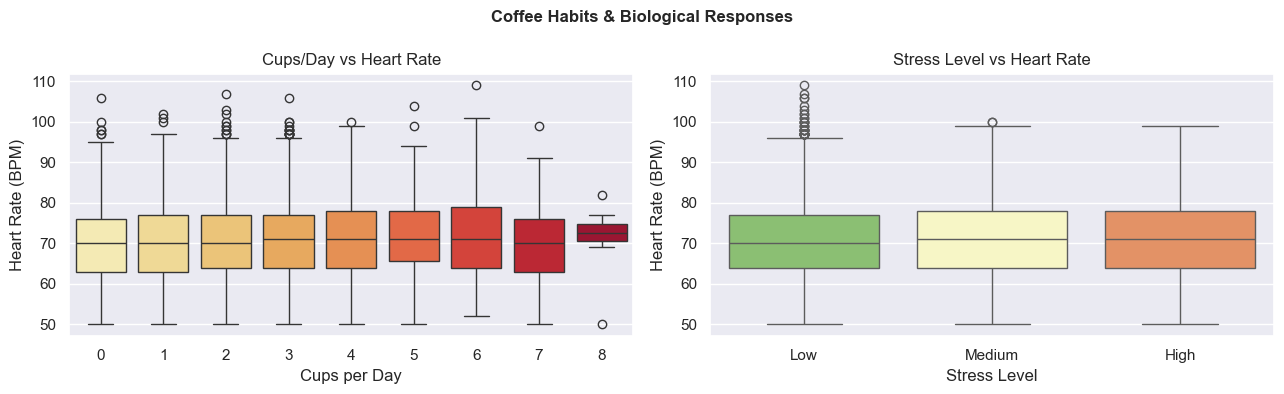

In [7]:
# ── 3d. Cups per day vs Stress ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['Cups_round'] = df['Coffee_Intake'].round().astype(int).clip(0,8)
sns.boxplot(data=df, x='Cups_round', y='Heart_Rate',
            palette='YlOrRd', ax=axes[0])
axes[0].set(title='Cups/Day vs Heart Rate', xlabel='Cups per Day', ylabel='Heart Rate (BPM)')

sns.boxplot(data=df, x='Stress_Level', y='Heart_Rate',
            order=['Low','Medium','High'], palette='RdYlGn_r', ax=axes[1])
axes[1].set(title='Stress Level vs Heart Rate', xlabel='Stress Level', ylabel='Heart Rate (BPM)')

plt.suptitle('Coffee Habits & Biological Responses', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC,'bio_04_cups_stress.png'), dpi=150, bbox_inches='tight')
plt.show()

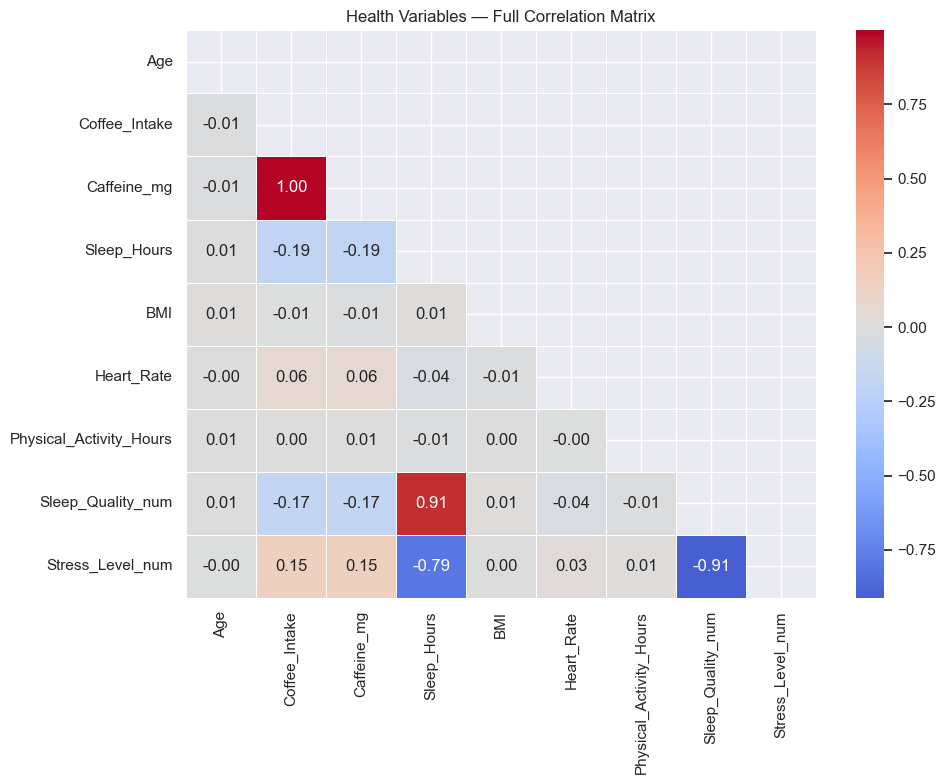

In [8]:
# ── 3e. Full correlation matrix ────────────────────────────────
num_cols = ['Age','Coffee_Intake','Caffeine_mg','Sleep_Hours',
            'BMI','Heart_Rate','Physical_Activity_Hours',
            'Sleep_Quality_num','Stress_Level_num']
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones((len(num_cols),len(num_cols)), dtype=bool))
sns.heatmap(df[num_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Health Variables — Full Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROC,'bio_05_corr_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── 3f. 3D Scatter (Plotly) ───────────────────────────────────
sample = df.sample(2000, random_state=42)
fig3d = px.scatter_3d(
    sample, x='Caffeine_mg', y='Sleep_Hours', z='Heart_Rate',
    color='Heart_Rate', color_continuous_scale='YlOrRd',
    opacity=0.5, size_max=5,
    labels={'Caffeine_mg':'Caffeine (mg)','Sleep_Hours':'Sleep (hrs)','Heart_Rate':'HR (BPM)'},
    title='Caffeine · Sleep · Heart Rate — 3D View'
)
fig3d.update_traces(marker=dict(size=3))
fig3d.show()

## 4 · ML Model — Heart Rate Predictor

In [10]:
FEATURES = ['Age','Coffee_Intake','Caffeine_mg','Sleep_Hours',
            'BMI','Physical_Activity_Hours','Sleep_Quality_num',
            'Stress_Level_num','Gender_enc','Smoking','Alcohol_Consumption']
FEATURES = [f for f in FEATURES if f in df.columns]
TARGET   = 'Heart_Rate'

df_model = df[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Features: {FEATURES}')
print(f'X shape: {X.shape}  |  HR range: {y.min()} – {y.max()} BPM')

Features: ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Physical_Activity_Hours', 'Sleep_Quality_num', 'Stress_Level_num', 'Gender_enc', 'Smoking', 'Alcohol_Consumption']
X shape: (10000, 11)  |  HR range: 50 – 109 BPM


In [11]:
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_sc, y, test_size=0.2, random_state=42
)

# Model A: Ridge (fast baseline, interpretable)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_r2 = r2_score(y_test, ridge.predict(X_test))

# Model B: Gradient Boosting (better for non-linear effects)
gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=3, subsample=0.8, random_state=42
)
gbr.fit(X_train, y_train)
y_pred  = gbr.predict(X_test)
rmse_hr = np.sqrt(mean_squared_error(y_test, y_pred))
mae_hr  = mean_absolute_error(y_test, y_pred)
r2_hr   = r2_score(y_test, y_pred)
cv_hr   = cross_val_score(gbr, X_sc, y, cv=5, scoring='r2')

print(f'Ridge R²  : {ridge_r2:.4f}')
print(f'GBR RMSE  : {rmse_hr:.3f} BPM')
print(f'GBR MAE   : {mae_hr:.3f} BPM')
print(f'GBR R²    : {r2_hr:.4f}')
print(f'CV R²     : {cv_hr.round(3)}  →  mean = {cv_hr.mean():.3f}')

Ridge R²  : 0.0035
GBR RMSE  : 9.906 BPM
GBR MAE   : 8.008 BPM
GBR R²    : -0.0009
CV R²     : [-0.012 -0.011 -0.006 -0.014 -0.016]  →  mean = -0.012


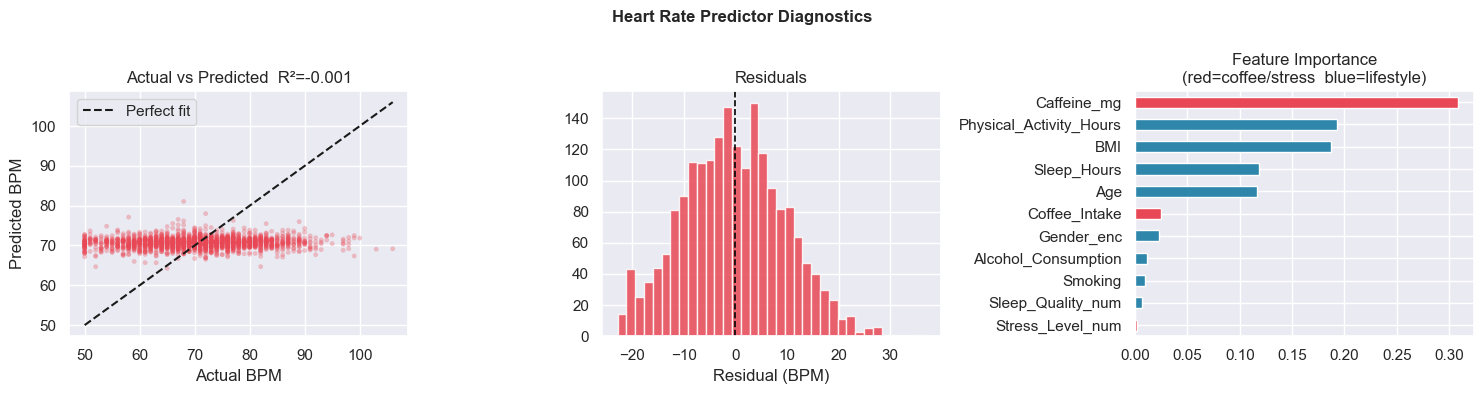

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color=C_PULSE, s=12, edgecolors='none')
mn, mx = float(y_test.min()), float(y_test.max())
axes[0].plot([mn,mx],[mn,mx],'k--',lw=1.5,label='Perfect fit')
axes[0].set(title=f'Actual vs Predicted  R²={r2_hr:.3f}',
            xlabel='Actual BPM', ylabel='Predicted BPM')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=35, color=C_PULSE, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.2, ls='--')
axes[1].set(title='Residuals', xlabel='Residual (BPM)')

# Feature importance
fi = pd.Series(gbr.feature_importances_, index=FEATURES).sort_values()
colors = [C_PULSE if 'Caffeine' in f or 'Coffee' in f or 'Stress' in f
          else C_CALM for f in fi.index]
fi.plot(kind='barh', color=colors, ax=axes[2])
axes[2].set(title='Feature Importance\n(red=coffee/stress  blue=lifestyle)')

plt.suptitle('Heart Rate Predictor Diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROC,'bio_06_model_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()

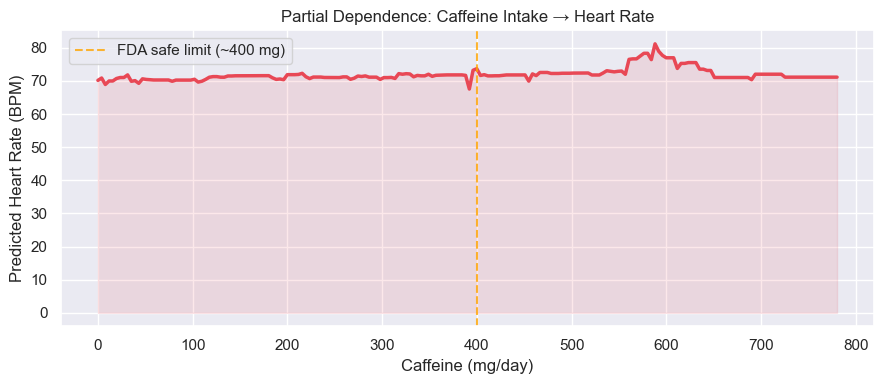

In [13]:
# ── Partial dependence: Caffeine alone → HR ───────────────────
caff_range = np.linspace(0, 780, 200)
X_demo = pd.DataFrame({f: [df[f].median()] * 200 for f in FEATURES})
X_demo['Caffeine_mg'] = caff_range
X_demo_sc = scaler.transform(X_demo[FEATURES])
hr_pred = gbr.predict(X_demo_sc)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(caff_range, hr_pred, color=C_PULSE, lw=2.5)
ax.fill_between(caff_range, hr_pred, alpha=0.12, color=C_PULSE)
ax.axvline(400, color='orange', ls='--', alpha=0.8, label='FDA safe limit (~400 mg)')
ax.set(title='Partial Dependence: Caffeine Intake → Heart Rate',
       xlabel='Caffeine (mg/day)', ylabel='Predicted Heart Rate (BPM)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROC,'bio_07_caffeine_pdp.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5 · Save All Artifacts

In [14]:
df[FEATURES + [TARGET]].dropna().to_csv(os.path.join(PROC,'bio_processed.csv'), index=False)
df.to_csv(os.path.join(PROC,'bio_full.csv'), index=False)

joblib.dump(gbr,    os.path.join(MDL,'heart_rate_predictor.pkl'))
joblib.dump(scaler, os.path.join(MDL,'health_scaler.pkl'))
joblib.dump(FEATURES, os.path.join(MDL,'health_features.pkl'))

print('✅  Notebook 3 complete!')
print(f'    HR Predictor R² = {r2_hr:.3f}  |  RMSE = {rmse_hr:.2f} BPM')
print('    Features:', FEATURES)

✅  Notebook 3 complete!
    HR Predictor R² = -0.001  |  RMSE = 9.91 BPM
    Features: ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours', 'BMI', 'Physical_Activity_Hours', 'Sleep_Quality_num', 'Stress_Level_num', 'Gender_enc', 'Smoking', 'Alcohol_Consumption']
